Cellule 1 : Importations & Chargement

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style Seaborn
sns.set_theme(style="whitegrid")

# Chargement des données
df = pd.read_csv('all_players_clean.csv')
df.head()

,Name,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,Sprint.Speed,...,Nation,League,Team,url,GK.Diving,GK.Handling,GK.Kicking,GK.Positioning,GK.Reflexes,gender
0,Kylian Mbappé,91,97,90,80,92,36,78,97,97,...,France,LALIGA EA SPORTS,Real Madrid,https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,M
1,Rodri,91,66,80,86,84,87,85,65,66,...,Spain,Premier League,Manchester City,https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,M
2,Erling Haaland,91,88,92,70,81,45,88,80,94,...,Norway,Premier League,Manchester City,https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,M
3,Jude Bellingham,90,80,87,83,88,78,83,81,80,...,England,LALIGA EA SPORTS,Real Madrid,https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,M
4,Vini Jr.,90,95,84,81,91,29,69,95,95,...,Brazil,LALIGA EA SPORTS,Real Madrid,https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,M


Cellule 2 : 1. Compréhension du dataset

In [2]:
# Quantitatives vs Qualitatives
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Quantitatives ({len(num_cols)}) :", num_cols)
print(f"Qualitatives ({len(cat_cols)}) :", cat_cols)

# Joueur avec la meilleure note OVR
best_players = df[df['OVR'] == df['OVR'].max()][['Name', 'OVR', 'Team', 'League']]
display(best_players)

# 5 ligues les plus représentées
df['League'].value_counts().head(5)

Quantitatives (46) : ['OVR', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY', 'Acceleration', 'Sprint.Speed', 'Positioning', 'Finishing', 'Shot.Power', 'Long.Shots', 'Volleys', 'Penalties', 'Vision', 'Crossing', 'Free.Kick.Accuracy', 'Short.Passing', 'Long.Passing', 'Curve', 'Dribbling', 'Agility', 'Balance', 'Reactions', 'Ball.Control', 'Composure', 'Interceptions', 'Heading.Accuracy', 'Def.Awareness', 'Standing.Tackle', 'Sliding.Tackle', 'Jumping', 'Stamina', 'Strength', 'Aggression', 'Weak.foot', 'Skill.moves', 'Height', 'Weight', 'Age', 'GK.Diving', 'GK.Handling', 'GK.Kicking', 'GK.Positioning', 'GK.Reflexes']
Qualitatives (9) : ['Name', 'Position', 'Preferred.foot', 'Alternative.positions', 'Nation', 'League', 'Team', 'url', 'gender']


,Name,OVR,Team,League
0,Kylian Mbappé,91,Real Madrid,LALIGA EA SPORTS
1,Rodri,91,Manchester City,Premier League
2,Erling Haaland,91,Manchester City,Premier League
16161,Aitana Bonmatí,91,FC Barcelona,Liga F


League
Sudamericana        826
MLS                 762
EFL Championship    683
EFL League One      615
Premier League      597
Name: count, dtype: int64

Résultat & Interprétation :

Distribution de la note générale (OVR) :
Le graphique montre une distribution normale (gaussienne) centrée autour de 67, avec un quantile à 25 % à 62 et un quantile à 75 % à 71. Les valeurs extrêmes (< 50 et > 85) restent rares, ce qui traduit un équilibre global de la population de joueurs.

Comparaison Vitesse (PAC) vs Physique (PHY) :
Les deux distributions sont dissymétriques. La vitesse (PAC, moyenne = 68,2) présente une dispersion plus étalée vers la droite, tandis que le physique (PHY, moyenne = 65,4) est plus concentré avec un écart-type plus faible (9,47 vs 10,59).

Densité du Dribble (DRI) :
La courbe de densité (KDE) est monomodale, symétrique et centrée sur la valeur 65, indiquant une capacité de dribble moyenne similaire pour une grande majorité de joueurs de champ.

Volume par Ligue et par Nation (countplot) :
Les volumes de joueurs sont dominés par les divisions anglaises et sud-américaines en nombre total. Côté nationalités, l'Angleterre, l'Allemagne, l'Espagne, la France et l'Argentine constituent le top 5, reflétant la structure des bases de données de recrutement.

Cellule 3 : 2. Visualisations UNIVARIÉES

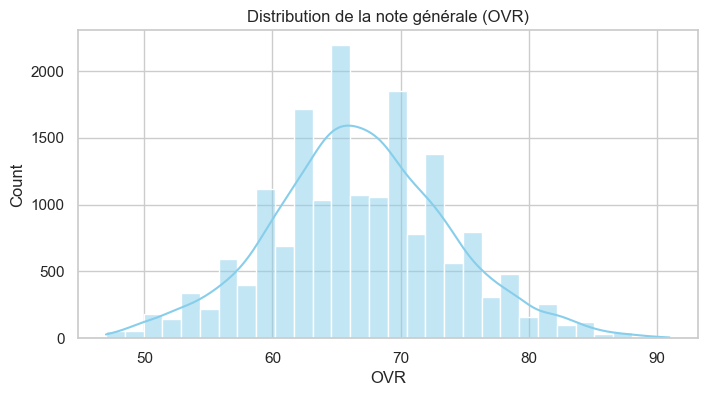

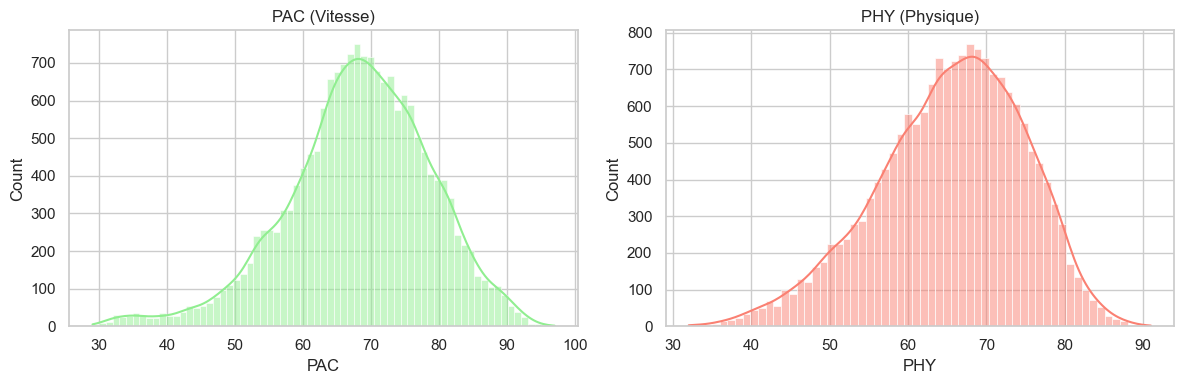

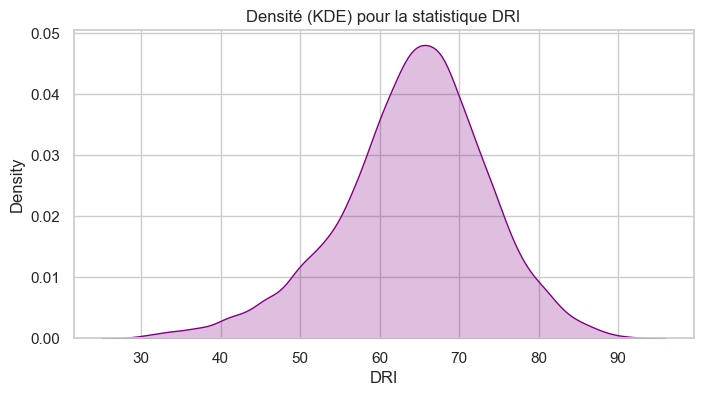

C:\Users\utilisateur\AppData\Local\Temp\ipykernel_17144\1932402312.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='League', order=top_leagues, palette='viridis', ax=axes[0])
C:\Users\utilisateur\AppData\Local\Temp\ipykernel_17144\1932402312.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Nation', order=top_nations, palette='magma', ax=axes[1])


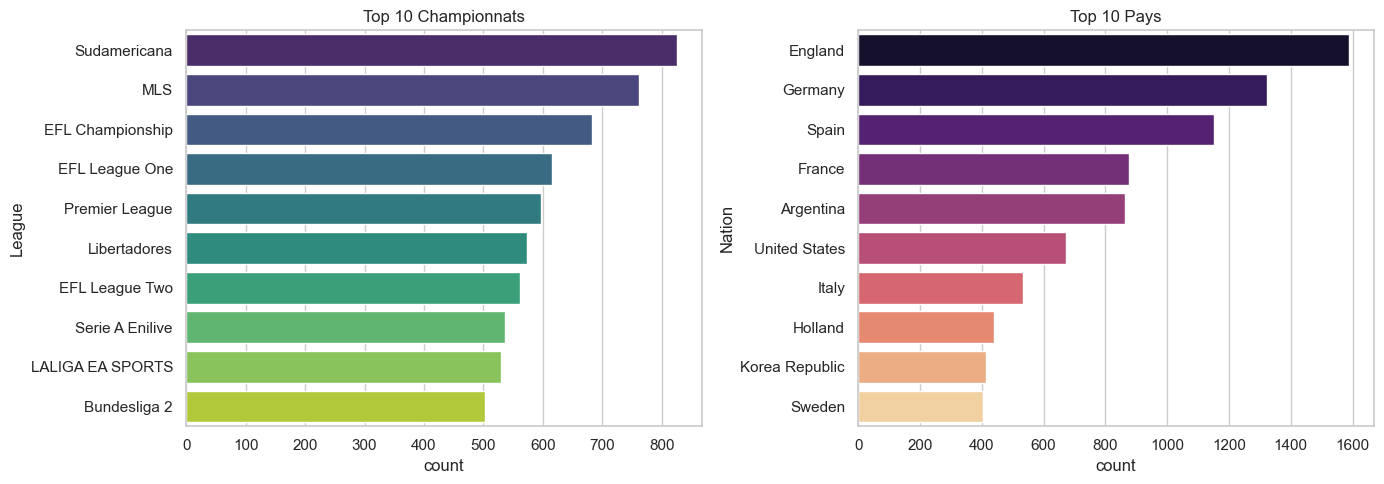

In [3]:
# Distribution OVR
plt.figure(figsize=(8, 4))
sns.histplot(df['OVR'], kde=True, color='skyblue', bins=30)
plt.title("Distribution de la note générale (OVR)")
plt.show()

# Comparaison PAC et PHY
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['PAC'], ax=axes[0], color='lightgreen', kde=True)
axes[0].set_title("PAC (Vitesse)")
sns.histplot(df['PHY'], ax=axes[1], color='salmon', kde=True)
axes[1].set_title("PHY (Physique)")
plt.tight_layout()
plt.show()

# Densité DRI
plt.figure(figsize=(8, 4))
sns.kdeplot(df['DRI'], fill=True, color='purple')
plt.title("Densité (KDE) pour la statistique DRI")
plt.show()

# Top championnats et pays
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_leagues = df['League'].value_counts().head(10).index
sns.countplot(data=df, y='League', order=top_leagues, palette='viridis', ax=axes[0])
axes[0].set_title("Top 10 Championnats")

top_nations = df['Nation'].value_counts().head(10).index
sns.countplot(data=df, y='Nation', order=top_nations, palette='magma', ax=axes[1])
axes[1].set_title("Top 10 Pays")
plt.tight_layout()
plt.show()

Cellule 4 : 3. Visualisations BIVARIÉES

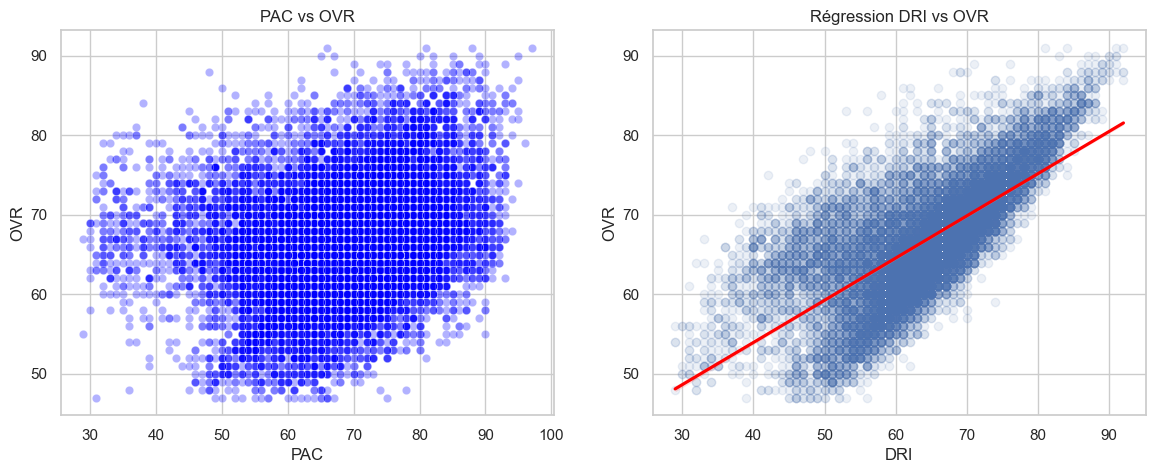

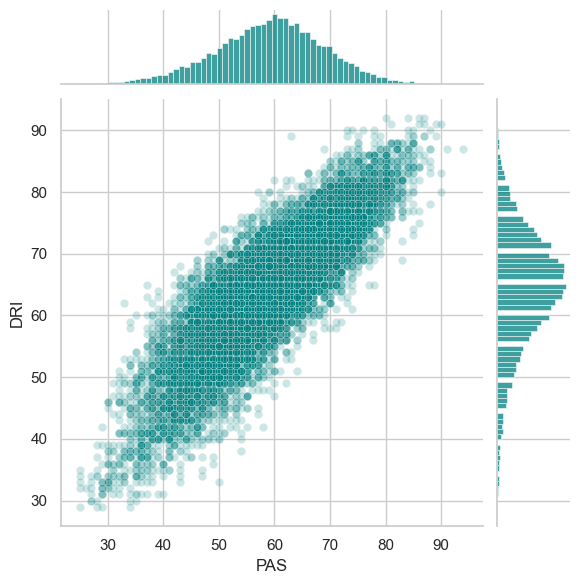

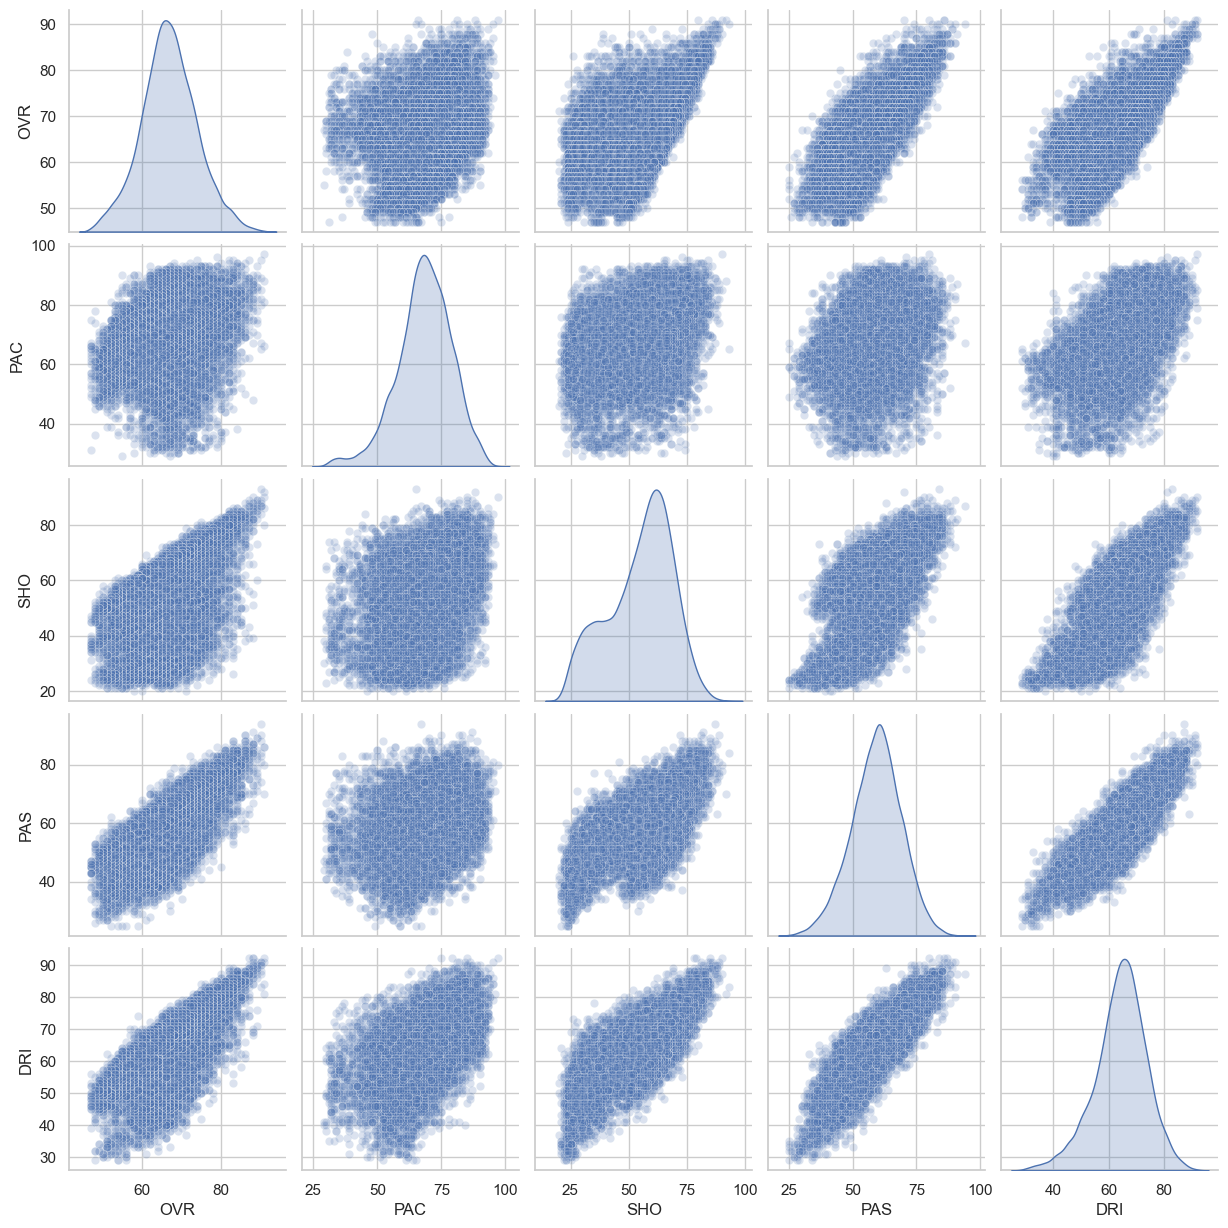

C:\Users\utilisateur\AppData\Local\Temp\ipykernel_17144\1502676266.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['League'].isin(top5_leagues)], x='League', y='OVR', palette='Set2')


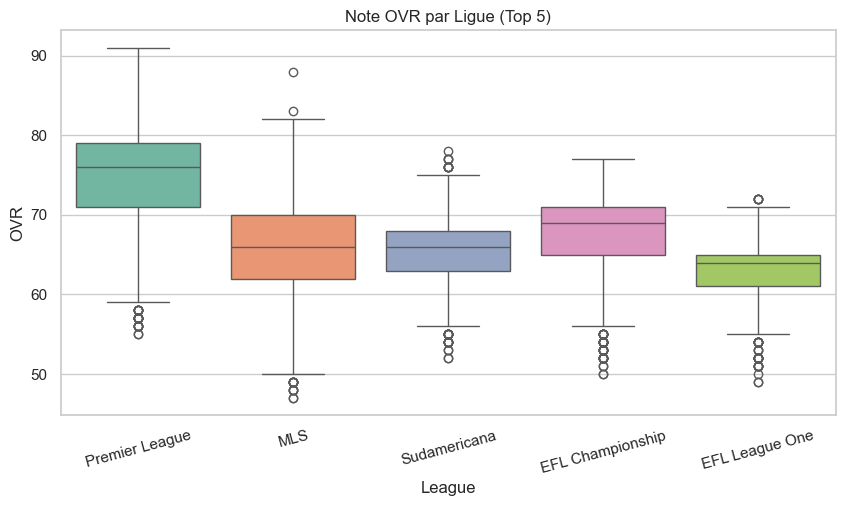

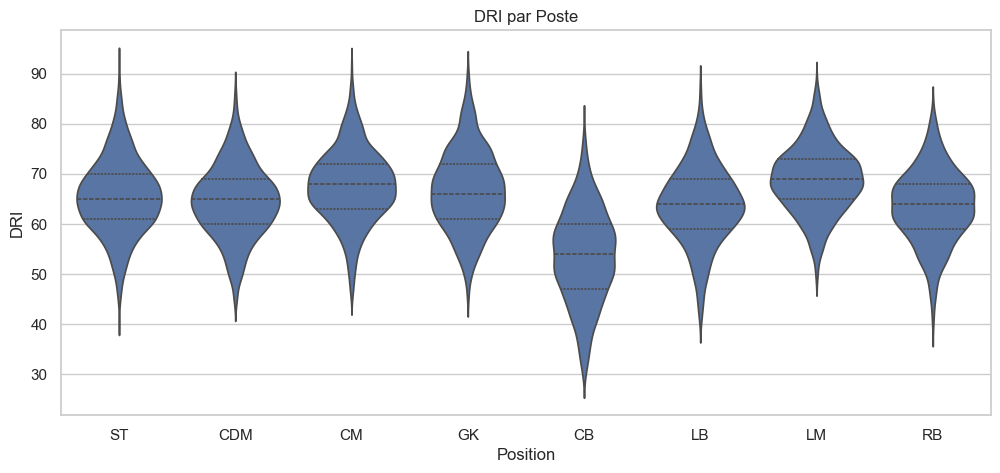

C:\Users\utilisateur\AppData\Local\Temp\ipykernel_17144\1502676266.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df[df['League'].isin(phy_order)], x='PHY', y='League', order=phy_order, palette='crest')


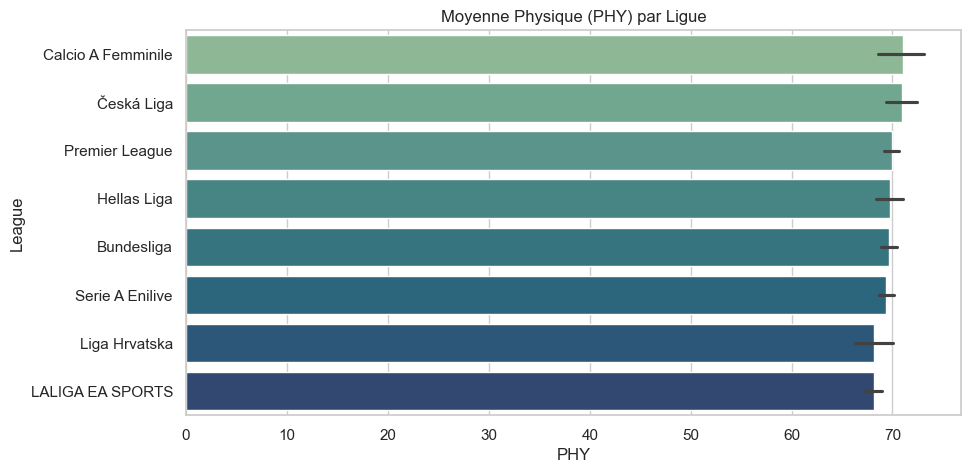

In [4]:
# Relation PAC vs OVR & Régression DRI vs OVR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='PAC', y='OVR', alpha=0.3, color='blue', ax=axes[0])
axes[0].set_title("PAC vs OVR")

sns.regplot(data=df, x='DRI', y='OVR', scatter_kws={'alpha':0.1}, line_kws={'color':'red'}, ax=axes[1])
axes[1].set_title("Régression DRI vs OVR")
plt.show()

# Jointplot PAS vs DRI
sns.jointplot(data=df, x='PAS', y='DRI', kind='scatter', alpha=0.2, color='teal')
plt.show()

# Pairplot complet
cols = ['OVR', 'PAC', 'SHO', 'PAS', 'DRI']
sns.pairplot(df[cols].dropna(), diag_kind='kde', plot_kws={'alpha':0.2})
plt.show()

# Boxplot OVR par League (Top 5 ligues)
plt.figure(figsize=(10, 5))
top5_leagues = df['League'].value_counts().head(5).index
sns.boxplot(data=df[df['League'].isin(top5_leagues)], x='League', y='OVR', palette='Set2')
plt.xticks(rotation=15)
plt.title("Note OVR par Ligue (Top 5)")
plt.show()

# Violinplot DRI par poste
plt.figure(figsize=(12, 5))
top_pos = df['Position'].value_counts().head(8).index
sns.violinplot(data=df[df['Position'].isin(top_pos)], x='Position', y='DRI', inner="quartile")
plt.title("DRI par Poste")
plt.show()

# Barplot Moyenne PHY par championnat
plt.figure(figsize=(10, 5))
phy_order = df.groupby('League')['PHY'].mean().sort_values(ascending=False).head(8).index
sns.barplot(data=df[df['League'].isin(phy_order)], x='PHY', y='League', order=phy_order, palette='crest')
plt.title("Moyenne Physique (PHY) par Ligue")
plt.show()

Cellule 5 : 4. Visualisations MULTIVARIÉES

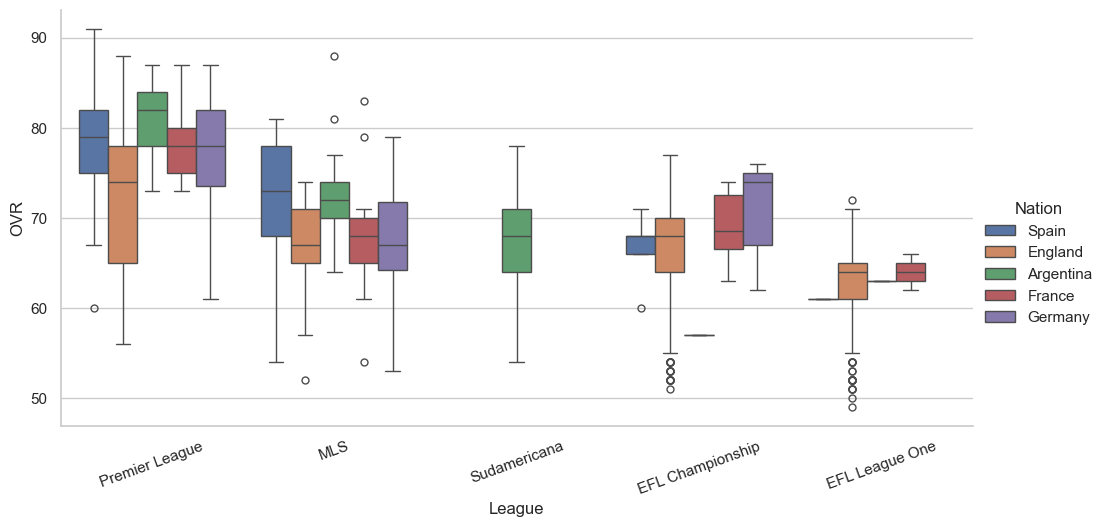

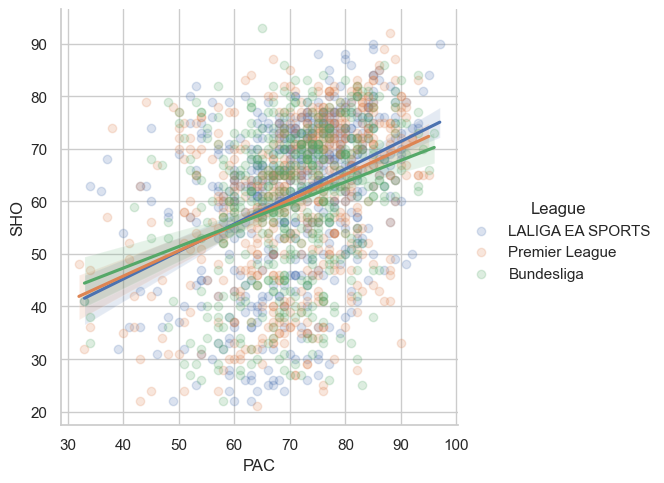

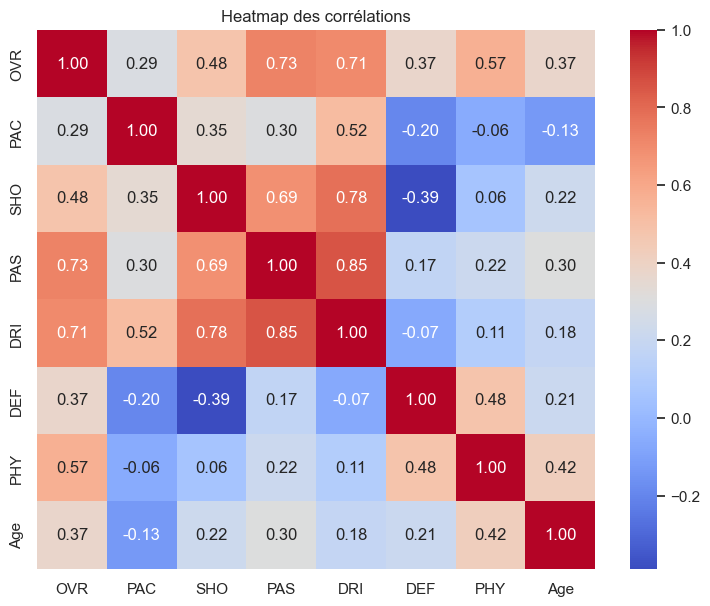

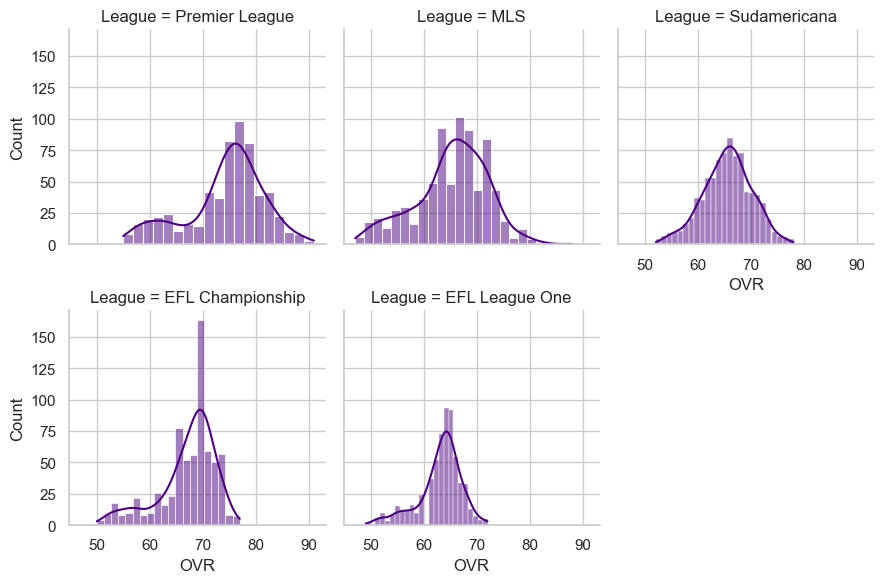

In [5]:
top5_nations = df['Nation'].value_counts().head(5).index
big3 = ['Premier League', 'LALIGA EA SPORTS', 'Bundesliga']

# Catplot OVR par Ligue et Nation
df_cat = df[(df['League'].isin(top5_leagues)) & (df['Nation'].isin(top5_nations))]
sns.catplot(data=df_cat, x='League', y='OVR', hue='Nation', kind='box', height=5, aspect=2)
plt.xticks(rotation=20)
plt.show()

# Lmplot PAC vs SHO
sns.lmplot(data=df[df['League'].isin(big3)], x='PAC', y='SHO', hue='League', scatter_kws={'alpha':0.2}, height=5)
plt.show()

# Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(df[['OVR', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY', 'Age']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap des corrélations")
plt.show()

# FacetGrid
g = sns.FacetGrid(df[df['League'].isin(top5_leagues)], col='League', col_wrap=3, height=3)
g.map(sns.histplot, 'OVR', kde=True, color='indigo')
plt.show()

Résultat & Interprétation :

Catplot : Met en évidence l'écart de niveau moyen (OVR) et la dispersion des joueurs selon la nationalité au sein des grands championnats.

Lmplot (PAC vs SHO) : Montre s'il existe une régression/relation positive entre la vitesse et la finition du joueur, tout en observant si une ligue se détache par des profils plus complets.

Heatmap : Permet d'identifier immédiatement les facteurs les plus influents sur l'OVR (généralement le dribble DRI et la passe PAS) ainsi que les attributs très liés entre eux (ex: vitesse et dribble vs défense et physique).

FacetGrid : Permet de comparer visuellement si la répartition du niveau des joueurs suit une loi normale dans chaque championnat ou si certaines ligues ont une concentration plus élevée de joueurs d'élite.

Cellule 6 : 5. Performance Sportive & 6. Exercices Avancés

C:\Users\utilisateur\AppData\Local\Temp\ipykernel_17144\583176400.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df[df['League'].isin(exp_order)], x='Explosivity', y='League', order=exp_order, palette='rocket')


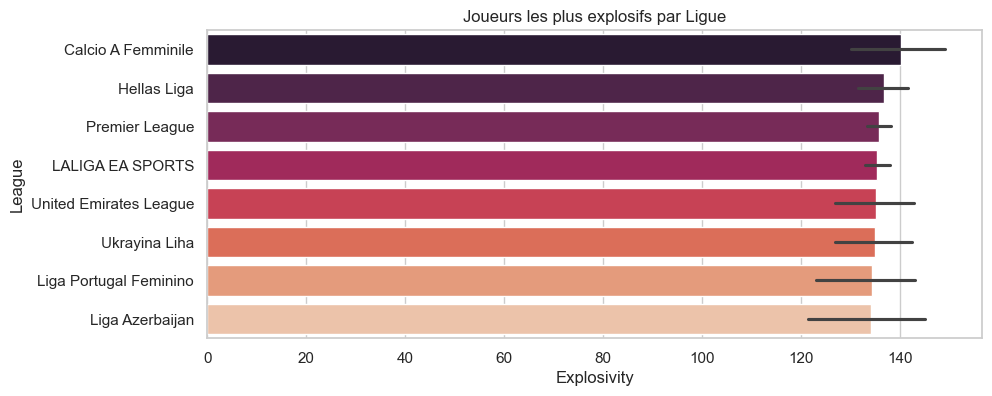

c:\Users\utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


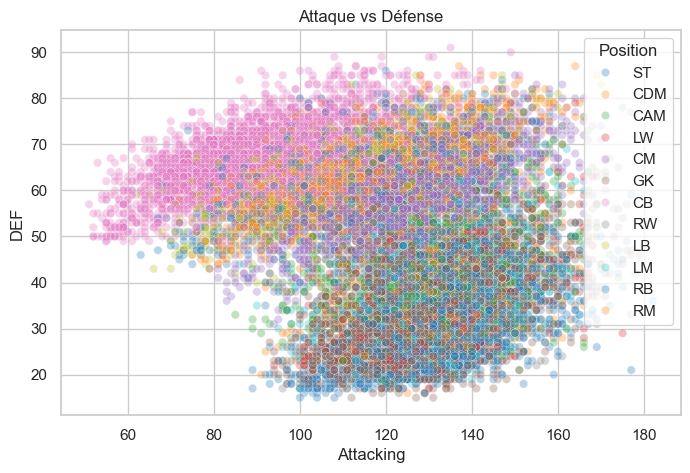

C:\Users\utilisateur\AppData\Local\Temp\ipykernel_17144\583176400.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_clubs[top_clubs['Team'].isin(club_order)], x='OVR', y='Team', order=club_order, palette='Blues_r')


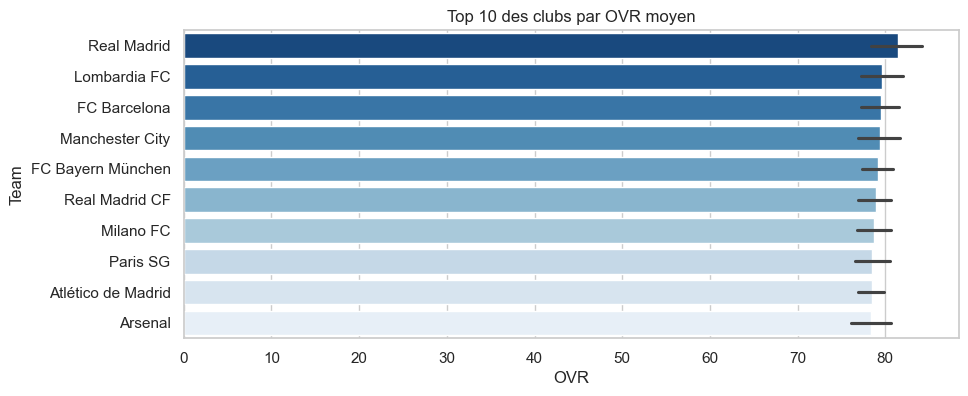

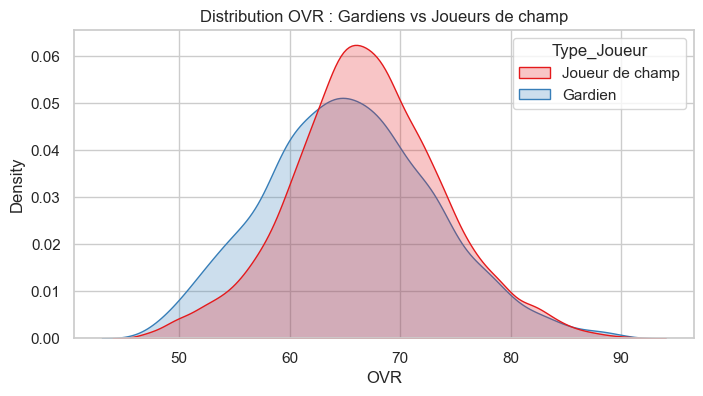

In [6]:
# Ligues les plus explosives
df['Explosivity'] = df['Acceleration'] + df['Sprint.Speed']
plt.figure(figsize=(10, 4))
exp_order = df.groupby('League')['Explosivity'].mean().sort_values(ascending=False).head(8).index
sns.barplot(data=df[df['League'].isin(exp_order)], x='Explosivity', y='League', order=exp_order, palette='rocket')
plt.title("Joueurs les plus explosifs par Ligue")
plt.show()

# Attaque vs Défense
df['Attacking'] = df['SHO'] + df['DRI']
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Attacking', y='DEF', alpha=0.3, hue='Position', palette='tab10')
plt.title("Attaque vs Défense")
plt.show()

# Top 10 Clubs OVR moyen
top_clubs = df.groupby('Team').filter(lambda x: len(x) >= 15)
club_order = top_clubs.groupby('Team')['OVR'].mean().sort_values(ascending=False).head(10).index
plt.figure(figsize=(10, 4))
sns.barplot(data=top_clubs[top_clubs['Team'].isin(club_order)], x='OVR', y='Team', order=club_order, palette='Blues_r')
plt.title("Top 10 des clubs par OVR moyen")
plt.show()

# Gardiens vs Joueurs de champ
df['Type_Joueur'] = df['Position'].apply(lambda x: 'Gardien' if x == 'GK' else 'Joueur de champ')
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x='OVR', hue='Type_Joueur', fill=True, common_norm=False, palette='Set1')
plt.title("Distribution OVR : Gardiens vs Joueurs de champ")
plt.show()